In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.load_data import load_real_data
df = pd.read_parquet("data/simulation/d=2_exp_marked_2e6.parquet")
print(len(df))

2220256


### Fonctions de plotting


In [4]:
def qqplot_gaussian_fit(df):
    n1h = 300
    def f(returns, color, label=None, ax=None, s=6, alpha=0.6):
        from scipy.stats import norm
        r = np.asarray(returns)
        r = r[np.isfinite(r)]
        r_sorted = np.sort(r)
        n = len(r_sorted)

        p = (np.arange(1, n + 1) - 0.5) / n

        mu = r_sorted.mean()
        sigma = r_sorted.std(ddof=1)

        q_theo = norm.ppf(p, loc=mu, scale=sigma)

        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))

        ax.scatter(r_sorted, q_theo, s=s, alpha=alpha, label=label, color=color)

        return ax, mu, sigma


    fig, ax = plt.subplots(figsize=(9,3))
    colors = plt.get_cmap("tab10").colors
    logp = np.log(df["price"].values)
    for i, n_ in enumerate([int(n1h/4), n1h, int(n1h*6), int(n1h*24)]):
        
        r_ = logp[n_:] - logp[:-n_]

        f(r_, color=colors[i+1], label=f"{n_} swaps", ax=ax, s=6, alpha=0.6)


    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    lo = min(xmin, ymin)
    hi = max(xmax, ymax)
    ax.plot([lo, hi], [lo, hi], "b--", linewidth=1)
    ax.set_ylabel("Quantiles of Gaussian fit")
    ax.set_xlabel("Quantiles of real data (log-return)")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")
    plt.show()
    

def plot_autocorr(returns, ax=None):
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(returns, lags=20, ax=ax)
    
def plot_logreturns_distribution(returns, ax=None):
    if ax is None:    
        fig, ax = plt.subplots(figsize=(8,3))
    from scipy.stats import norm
    ax.hist(returns, bins=100, density=True, alpha=0.8)
    x = np.linspace(returns.min(), returns.max(), 500)
    ax.plot(x, norm.pdf(x, returns.mean(), returns.std()), color="red")
    
def plot_events(df, ax=None):
    if ax is None:    
        fig, ax = plt.subplots(figsize=(8,3))
    ax1 = ax
    ax2 = ax1.twinx()
    
    swap = df[df["event_type"] == "swap"]["time"].values
    mint = df[df["event_type"] == "mint"]["time"].values
    burn = df[df["event_type"] == "burn"]["time"].values
    N1 = np.arange(1, len(swap)+1, 1)
    N2 = np.arange(1, len(mint)+1, 1)
    N3 = np.arange(1, len(burn)+1, 1)
    ax1.step(swap, N1, where="post", label="swap")
    ax2.step(mint, N2, where="post", color="g", linewidth=0.8, label="mint")
    ax2.step(burn, N3, where="post", color="r", linewidth=0.8, label="burn")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")


def plot_multiple_events(dfs, ax=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax1 = ax
    ax2 = ax1.twinx()

    if labels is None:
        labels = [f"df_{i}" for i in range(len(dfs))]
    items = list(zip(labels, dfs))

    for name, df in items:
        df = df.sort_values("time")

        for event_type, axis, color in [
            ("swap", ax1, None),
            ("mint", ax2, "g"),
            ("burn", ax2, "r"),
        ]:
            times = df.loc[df["event_type"] == event_type, "time"].values

            if len(times) == 0:
                continue

            counts = np.arange(1, len(times) + 1)

            # label explicite pour distinguer les dfs
            label = f"{name} - {event_type}"

            axis.step(
                times,
                counts,
                where="post",
                label=label,
                color=color,
                alpha=0.8
            )

    ax1.set_xlabel("time")
    ax1.set_ylabel("swap count")
    ax2.set_ylabel("mint / burn count")

    ax1.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    return ax1, ax2


def plot_tail(returns, ax=None):
    if ax is None:    
        fig, ax = plt.subplots(figsize=(8,3))
    r = np.sort(np.abs(returns))
    r = r[r > np.percentile(r, 90)]
    ccdf = 1 - np.arange(1, len(r)+1)/len(r)
    ax.step(r, ccdf)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("x")
    ax.set_ylabel(r"P(r > x)")

def plot_price(price, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(price)    
    ax.set_xlabel("t")
    ax.set_ylabel("price")
      

def detect_sandwich_attack(pool):
    sands = []
    swaps_only = pool.loc[pool["event_type"] == "swap"].copy()
    swaps_only = swaps_only.sort_values(
        ["transaction.blockNumber", "logIndex"],
        kind="mergesort"
    )
    for block_number, block_df in swaps_only.groupby("transaction.blockNumber", sort=False):
        if len(block_df) < 3:
            continue
        rows = list(block_df.itertuples(index=False))
        n = len(rows)
        next_x2y = {}
        next_y2x = {}
        back_idx_for_pos = [None] * n
        for i in range(n - 1, -1, -1):
            row = rows[i]
            sender = row.sender

            is_x2y = getattr(row, "SwapX2Y", False)
            is_y2x = getattr(row, "SwapY2X", False)

            if is_x2y:
                back_idx_for_pos[i] = next_y2x.get(sender)
                next_x2y[sender] = i

            elif is_y2x:
                back_idx_for_pos[i] = next_x2y.get(sender)
                next_y2x[sender] = i

        for i in range(n):
            back_idx = back_idx_for_pos[i]
            if back_idx is None:
                continue

            if back_idx - i < 2:
                continue

            front = rows[i]
            back = rows[back_idx]
            victims = rows[i + 1:back_idx]
            if victims:
                sands.append((front, back, victims))
    return sands



## Uniswap v3 Pools analysés (Ethereum Mainnet)

- **USDC/WETH – 0.05% - 0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640**  
  token0 = USDC (6d), token1 = WETH (18d) | 230249 events - 307 swaps/h

- **USDC/WETH – 0.30% - 0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8**  
  token0 = USDC (6d), token1 = WETH (18d) | 27757 events - 35 swaps/h

- **WBTC/WETH – 0.05% - 0x11b815efb8f581194ae79006d24e0d814b7697f6**  
  token0 = WBTC (8d), token1 = WETH (18d) | 151283 events - 207 swaps/h
 
- **WBTC/WETH – 0.30% - 0xcbcdf9626bc03e24f779434178a73a0b4bad62ed**  
  token0 = WBTC (8d), token1 = WETH (18d) | 13569 events - 16 swaps/h

- **USDC/USDT – 0.01% - 0x3416cf6c708da44db2624d63ea0aaef7113527c6**  
  token0 = USDC (6d), token1 = USDT (6d) | 45334 events - 59 swaps/h

In [17]:
from src.load_data import load_real_data

df = load_real_data("USDC/USDT 0.01")
df = df[df["event_type"] == "burn"]
len(df)

1627

In [58]:
df1 = df_discrete = df.groupby(
    ['transaction.blockNumber', 'process'],
    as_index=False
).agg(count=('event_type', 'count'))

df1["time"] = df1["transaction.blockNumber"] - df1["transaction.blockNumber"].iloc[0]
df1

,transaction.blockNumber,process,count,time
0,24257914,X2Y,1,0
1,24257917,X2Y,1,3
2,24257920,X2Y,1,6
3,24257923,X2Y,2,9
4,24257924,X2Y,1,10
...,...,...,...,...
139902,24472820,X2Y,1,214906
139903,24472820,Y2X,2,214906
139904,24472822,X2Y,3,214908
139905,24472822,Y2X,1,214908


Proportion de blocs vides : 46.78%
Nombre moyen de swaps par bloc : 1.03
Nombre médian de swaps par bloc : 1.00


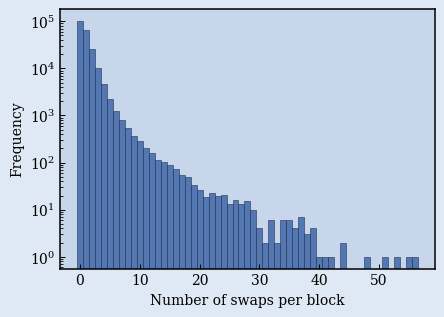

In [2]:
from src.load_data import load_real_data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

df = load_real_data("USDC/WETH 0.05")
df = df[df["event_type"] == "swap"]

counts = df.groupby("transaction.blockNumber").size()
all_blocks = np.arange(df["transaction.blockNumber"].min(), df["transaction.blockNumber"].max() + 1)
counts_all = counts.reindex(all_blocks, fill_value=0)
bins = np.arange(-0.5, counts_all.max() + 1.5, 1)
prop_empty = (counts_all == 0).mean()
print(f"Proportion de blocs vides : {100*(counts_all==0).mean():.2f}%")
print(f"Nombre moyen de swaps par bloc : {counts_all.mean():.2f}")
print(f"Nombre médian de swaps par bloc : {counts_all.median():.2f}")
def set_article_style():
    mpl.rcParams.update({
        "figure.facecolor": "#dfe8f5",
        "axes.facecolor": "#c8d6eb",
        "axes.edgecolor": "#000000",
        "axes.linewidth": 1.1,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "legend.frameon": True,
        "legend.facecolor": "#dfe8f5",
        "legend.edgecolor": "#666666",
        "savefig.facecolor": "#dfe8f5",
    })

set_article_style()

fig, ax = plt.subplots(figsize=(5, 3.2))
fig.subplots_adjust(left=0.13, right=0.88, bottom=0.16, top=0.97)
ax.hist(counts_all, bins=bins, log=True, color="#4c72b0", edgecolor="#1f2a44", linewidth=0.4, alpha=0.95)
ax.set_xlabel("Number of swaps per block")
ax.set_ylabel("Frequency")
fig.patch.set_facecolor("#dfe8f5")
fig.savefig("swaps_per_block.pdf", bbox_inches=mpl.transforms.Bbox([[0, 0], [5, 3.2]]))
plt.show()

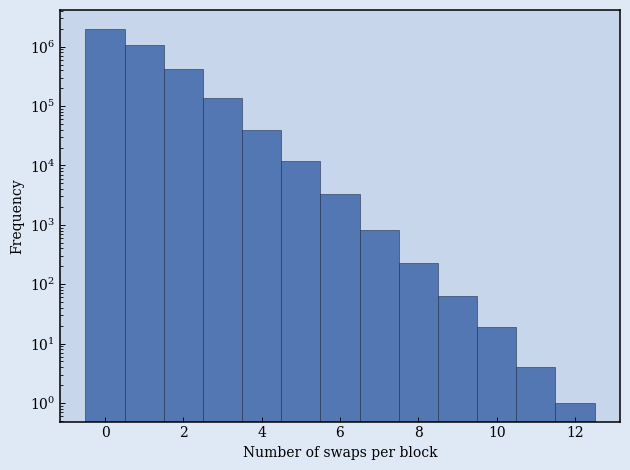

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_parquet("data/simulation/M5_block.parquet")
df.head()

counts = df.groupby("block_number").size()

all_blocks = np.arange(
    df["block_number"].min(),
    df["block_number"].max() + 1
)

counts_all = counts.reindex(all_blocks, fill_value=0)

bins = np.arange(-0.5, counts_all.max() + 1.5, 1)

import matplotlib as mpl


def set_article_style():
    mpl.rcParams.update({

        # fond global très clair
        "figure.facecolor": "#dfe8f5",

        # fond des sous-graphes légèrement plus foncé
        "axes.facecolor": "#c8d6eb",

        # bordures discrètes
        "axes.edgecolor": "#000000",
        "axes.linewidth": 1.1,

        # police
        "font.family": "serif",
        "mathtext.fontset": "cm",

        # ticks
        "xtick.direction": "in",
        "ytick.direction": "in",

        # ticks fins
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,

        # légende
        "legend.frameon": True,
        "legend.facecolor": "#dfe8f5",
        "legend.edgecolor": "#666666",

        # savefig cohérent
        "savefig.facecolor": "#dfe8f5",
    })

set_article_style()

fig, ax = plt.subplots()

ax.hist(
    counts_all,
    bins=bins,
    log=True,
    color="#4c72b0",
    edgecolor="#1f2a44",
    linewidth=0.4,
    alpha=0.95
)
ax.set_xlabel("Number of swaps per block")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("swaps_per_block.pdf")
plt.show()

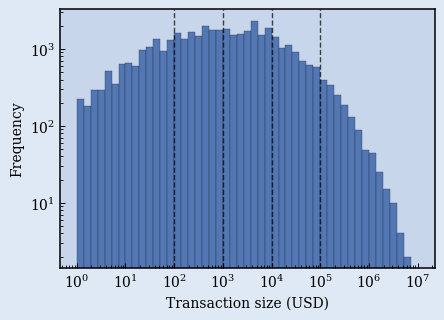

In [3]:
from src.load_data import load_real_data
import numpy as np
import matplotlib.pyplot as plt

df = load_real_data("USDC/USDT 0.01")
volume = df[df["event_type"] == "swap"]["amountUSD"].copy()

set_article_style()

fig, ax = plt.subplots(figsize=(5, 3.2))
fig.subplots_adjust(left=0.13, right=0.88, bottom=0.16, top=0.97)
ax.hist(volume, bins=np.logspace(0, 7, 50), color="#4c72b0", edgecolor="#1f2a44", linewidth=0.25, alpha=0.95)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Transaction size (USD)")
ax.set_ylabel("Frequency")
for x in [1e2, 1e3, 1e4, 1e5]:
    ax.axvline(x, color="#000000", linestyle="--", linewidth=1.0, alpha=0.7)
fig.patch.set_facecolor("#dfe8f5")
fig.savefig("figures/transaction_volume_distribution.pdf", bbox_inches=mpl.transforms.Bbox([[0, 0], [5, 3.2]]))
plt.show()

(<Axes: xlabel='time', ylabel='swap count'>,
 <Axes: ylabel='mint / burn count'>)

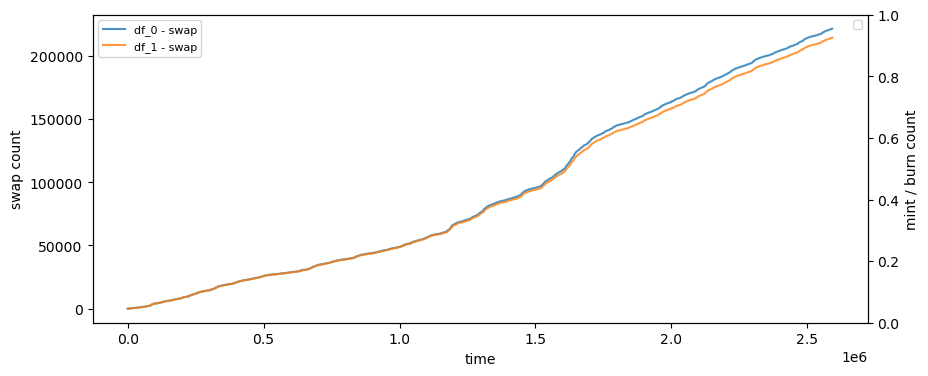

In [ ]:
df2 = df.groupby("transaction.blockNumber").head(10)
plot_multiple_events([df, df2])


swap : 221372
mint : 4624
burn : 4253


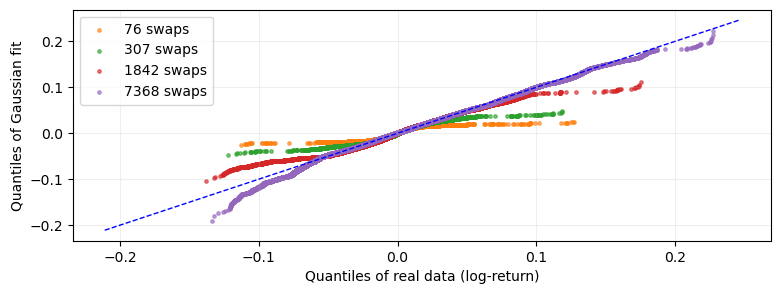

In [ ]:
qqplot_gaussian_fit(df)


n=307  kurtosis = 8.79
n=1845  kurtosis = 4.82
n=7379  kurtosis = 2.81


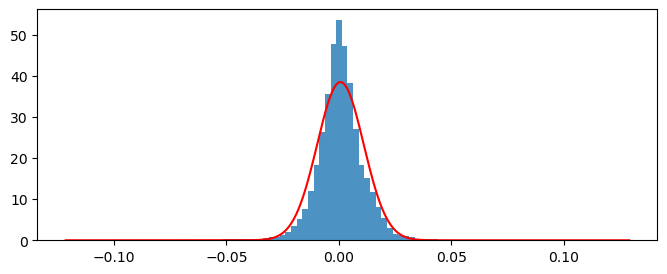

In [ ]:
logp = np.log(df["price"].values)
n=300
returns = (logp[n:] - logp[:-n])
returns = returns[~np.isnan(returns)]
    
plot_logreturns_distribution(returns)

from scipy.stats import kurtosis

for n_ in [307, 1845, 7379]:
    r = logp[n_:] - logp[:-n_]
    r = r[np.isfinite(r)]
    print(f"n={n_}  kurtosis = {kurtosis(r, fisher=False):.2f}")


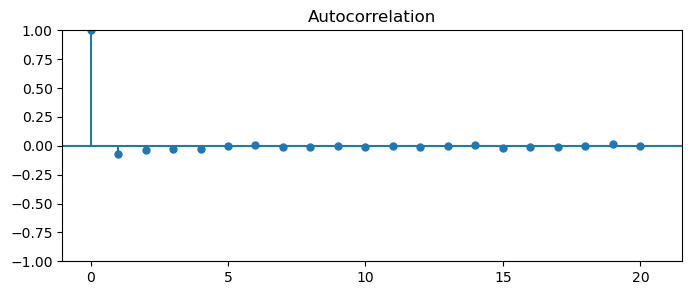

In [ ]:
n=1
returns = (logp[n::n] - logp[:-n:n])
returns = returns[~np.isnan(returns)]

plot_autocorr(returns)

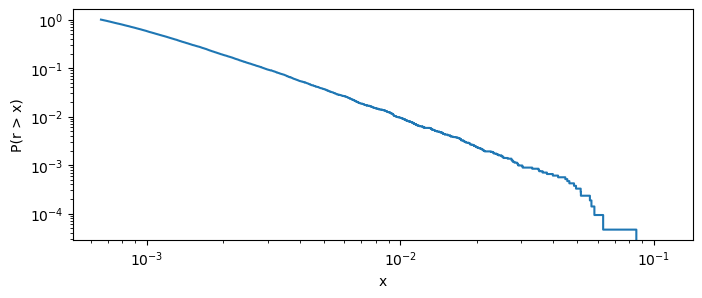

In [ ]:
plot_tail(returns)

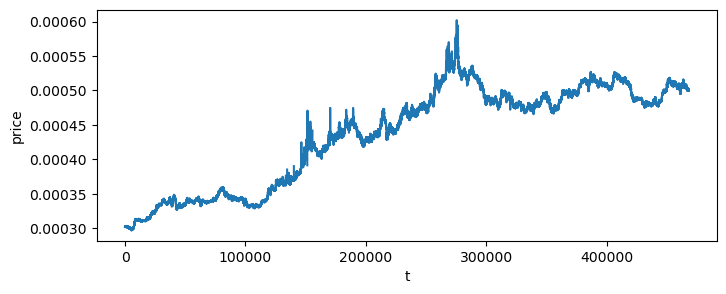

In [ ]:
  
plot_price(df["price"])

In [6]:
import pandas as pd
from src.load_data import load_real_data
df = load_real_data("USDC/WETH 0.05", file="365days")
print(len(df))


205145


In [ ]:
sands = detect_sandwich_attack(df)
print(len(sands))

print(round(len(sands)/len(df[df["event_type"] == "swap"])*100, 2))

0.47


In [ ]:
import numpy as np
df = load_real_data("USDC/WETH 0.05")
df = df[df["event_type"]=="swap"]["amountUSD"]


In [21]:
df.describe()

count    2.213720e+05
mean     2.828349e+04
std      1.003155e+05
min      1.900000e-15
25%      1.419284e+02
50%      2.412755e+03
75%      1.627946e+04
max      1.008026e+07
Name: amountUSD, dtype: float64

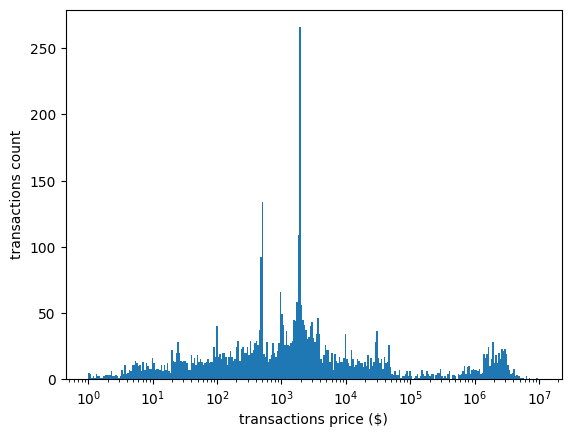

In [40]:
mint = df[df["event_type"]=="mint"]["amountUSD"].copy()

plt.hist(mint, bins=np.logspace(0, 7, 300))
plt.xscale("log")
plt.xlabel("transactions price ($)")
plt.ylabel("transactions count")
plt.show()

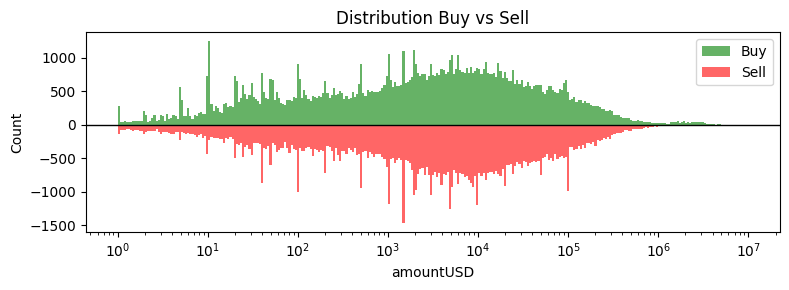

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bins logarithmiques
bins = np.logspace(0, 7, 300)

# Séparation buy / sell
buy = df.loc[df["SwapX2Y"], "amountUSD"].dropna()
sell = df.loc[~df["SwapX2Y"], "amountUSD"].dropna()

# Histogrammes
buy_hist, edges = np.histogram(buy, bins=bins)
sell_hist, _ = np.histogram(sell, bins=bins)

# Centres des bins
centers = np.sqrt(edges[:-1] * edges[1:])  # mieux pour échelle log

# Plot
plt.figure(figsize=(8, 3))

# Buy vers le haut
plt.bar(
    centers,
    buy_hist,
    width=np.diff(edges),
    color="green",
    alpha=0.6,
    label="Buy",
    align="center"
)

# Sell vers le bas
plt.bar(
    centers,
    -sell_hist,
    width=np.diff(edges),
    color="red",
    alpha=0.6,
    label="Sell",
    align="center"
)

plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("amountUSD")
plt.ylabel("Count")
plt.title("Distribution Buy vs Sell")
plt.legend()

plt.tight_layout()
plt.show()

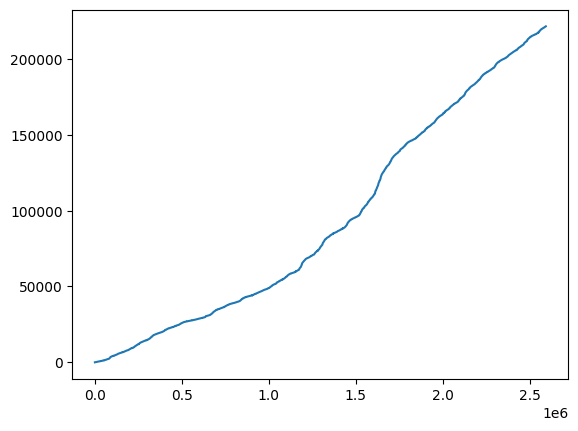

In [16]:
from src.load_data import load_real_data
df = load_real_data("USDC/WETH 0.05", file="30days")
df = df[df["event_type"]=="swap"]
t = df["time"]
N = np.arange(1, len(df)+1)
plt.plot(t, N)

In [28]:
from src.load_data import load_real_data
df_raw   = load_real_data(file="30days")

print(df_raw.columns)

Index(['amount0', 'amount1', 'amountUSD', 'id', 'logIndex', 'origin',
       'recipient', 'sender', 'sqrtPriceX96', 'tick', 'timestamp', 'pool',
       'event_type', 'amount', 'owner', 'tickLower', 'tickUpper',
       'transaction.blockNumber', 'transaction.gasPrice',
       'transaction.gasUsed', 'transaction.id', 'transaction.timestamp',
       'price_1_per_0', 't', 'time', 'process', 'price_factor', 'price',
       'SwapX2Y', 'SwapY2X'],
      dtype='str')
